In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.style.use('default')
sns.set_palette("hls")
%matplotlib inline

file_path = r"C:\Users\Мартинсон Диана\cars\data\processed\cleaned_cars.csv"
df = pd.read_csv(file_path)
print(f"Анализируем {len(df)} автомобилей")

columns_to_drop = ['price_number', 'price_cleaned']  
df_clean = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

pd.set_option('display.max_columns', None) 
pd.set_option('display.width', 1000)       
pd.set_option('display.max_colwidth', 30)   

print("\nСтруктура данных:")
print(f"Колонки: {list(df_clean.columns)}")
print(f"Всего колонок: {len(df_clean.columns)}")

print("\nПервые 5 строк данных (исправленное отображение):")
print(df_clean.head())

print("\nОсновная информация о данных:")
print(df_clean.info())

Анализируем 50 автомобилей

Структура данных:
Колонки: ['location', 'price', 'params', 'id', 'description', 'title', 'url', 'date', 'engine', 'mileage', 'brand', 'year', 'age']
Всего колонок: 13

Первые 5 строк данных (исправленное отображение):
                        location     price                         params          id                    description                          title                            url   date             engine     mileage    brand  year  age
0  Краснодарский край, Курган...  599000.0  145 000 км, 1.6 MT (106 л....  7694440136  145 000 км, 1.6 MT (106 л....  ВАЗ (LADA) Vesta 1.6 MT, 2...  https://www.avito.ru/kurga...    NaN  1.6 MT (106 л.с.)  145 000 км     Lada  2019    6
1  Краснодарский край, Краснодар  750000.0  181 000 км, 1.6 MT (106 л....  7696299040  181 000 км, 1.6 MT (106 л....  ВАЗ (LADA) Priora 1.6 MT, ...  https://www.avito.ru/krasn...    NaN  1.6 MT (106 л.с.)  181 000 км     Lada  2018    7
2            Тульская обл., Тула  915000.0 

In [2]:
import pandas as pd
import numpy as np
import os

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', 50)

file_path = r"C:\Users\Мартинсон Диана\cars\data\processed\cleaned_cars.csv"
df_clean = pd.read_csv(file_path)

if 'region' not in df_clean.columns and 'location' in df_clean.columns:
    df_clean['region'] = df_clean['location'].str.split(',').str[0]

with open('полный_анализ.txt', 'w', encoding='utf-8') as f:
    
    f.write("=" * 60 + "\n")
    f.write("🚗 ПОЛНЫЙ АНАЛИЗ ДАННЫХ AVITO\n")
    f.write("=" * 60 + "\n\n")
    
    f.write("📊 ОСНОВНАЯ СТАТИСТИКА:\n")
    f.write(f"• Всего автомобилей: {len(df_clean)}\n")
    f.write(f"• Средняя цена: {df_clean['price'].mean():.0f} руб\n")
    f.write(f"• Медианная цена: {df_clean['price'].median():.0f} руб\n")
    f.write(f"• Минимальная цена: {df_clean['price'].min():.0f} руб\n")
    f.write(f"• Максимальная цена: {df_clean['price'].max():.0f} руб\n")
    f.write(f"• Диапазон годов: {df_clean['year'].min()} - {df_clean['year'].max()}\n")
    f.write(f"• Уникальных марок: {df_clean['brand'].nunique()}\n\n")
    
    f.write("📈 ДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА:\n")
    f.write(f"• Общее количество автомобилей: {len(df_clean)}\n")
    f.write(f"• Уникальных марок: {df_clean['brand'].nunique()}\n")
    
    if 'region' in df_clean.columns:
        f.write(f"• Регионов представлено: {df_clean['region'].nunique()}\n")
    else:
        f.write(f"• Уникальных локаций: {df_clean['location'].nunique()}\n")
    
    f.write("\n💰 ЭКСТРЕМАЛЬНЫЕ ЦЕНЫ:\n")
    most_expensive = df_clean.loc[df_clean['price'].idxmax()]
    cheapest = df_clean.loc[df_clean['price'].idxmin()]
    
    f.write(f"• Самый дорогой автомобиль:\n")
    f.write(f"  {most_expensive['brand']} - {most_expensive['price']:.0f} руб. ({most_expensive['year']} год)\n")
    
    f.write(f"• Самый бюджетный автомобиль:\n")
    f.write(f"  {cheapest['brand']} - {cheapest['price']:.0f} руб. ({cheapest['year']} год)\n")
    
    f.write("\n🏆 ТОП МАРОК АВТОМОБИЛЕЙ:\n")
    top_brands = df_clean['brand'].value_counts()
    for i, (brand, count) in enumerate(top_brands.items(), 1):
        percentage = (count / len(df_clean)) * 100
        f.write(f"  {i}. {brand}: {count} авто ({percentage:.1f}%)\n")
    
    if 'age' in df_clean.columns:
        f.write(f"\n📅 ВОЗРАСТ АВТОМОБИЛЕЙ:\n")
        f.write(f"• Средний возраст: {df_clean['age'].mean():.1f} лет\n")
        f.write(f"• Самый старый: {df_clean['age'].max()} лет\n")
        f.write(f"• Самый новый: {df_clean['age'].min()} лет\n")
    
        f.write("\n🔍 ПРОВЕРКА НАЛИЧИЯ ДАННЫХ:\n")
    f.write(f"Колонки в данных: {list(df_clean.columns)}\n")
    
    if 'mileage_km' in df_clean.columns:
        valid_mileage = df_clean['mileage_km'].notna().sum()
        if valid_mileage > 0:
            f.write(f"\n🛣️  СТАТИСТИКА ПО ПРОБЕГУ:\n")
            f.write(f"• Записей с пробегом: {valid_mileage}\n")
            f.write(f"• Средний пробег: {df_clean['mileage_km'].mean():.0f} км\n")
            f.write(f"• Минимальный пробег: {df_clean['mileage_km'].min():.0f} км\n")
            f.write(f"• Максимальный пробег: {df_clean['mileage_km'].max():.0f} км\n")
        else:
            f.write("• Данные о пробеге отсутствуют\n")
    else:
        f.write("• Колонка 'mileage_km' не найдена\n")
    
    if 'engine_size' in df_clean.columns:
        valid_engine = df_clean['engine_size'].notna().sum()
        if valid_engine > 0:
            f.write(f"\n⚙️  СТАТИСТИКА ПО ДВИГАТЕЛЮ:\n")
            f.write(f"• Записей с объемом двигателя: {valid_engine}\n")
            f.write(f"• Средний объем: {df_clean['engine_size'].mean():.1f} л\n")
            f.write(f"• Минимальный объем: {df_clean['engine_size'].min():.1f} л\n")
            f.write(f"• Максимальный объем: {df_clean['engine_size'].max():.1f} л\n")
        else:
            f.write("• Данные об объеме двигателя отсутствуют\n")
    else:
        f.write("• Колонка 'engine_size' не найдена\n")
    
    # ГЕОГРАФИЯ ОБЪЯВЛЕНИЙ
    f.write(f"\n🌍 ГЕОГРАФИЯ ОБЪЯВЛЕНИЙ:\n")
    if 'region' in df_clean.columns:
        top_regions = df_clean['region'].value_counts()
        f.write("Топ регионов:\n")
        for i, (region, count) in enumerate(top_regions.items(), 1):
            f.write(f"  {i}. {region}: {count} авто\n")
    else:
        top_locations = df_clean['location'].value_counts()
        f.write("Топ локаций:\n")
        for i, (location, count) in enumerate(top_locations.items(), 1):
            f.write(f"  {i}. {location}: {count} авто\n")
    
    f.write("\n" + "=" * 60 + "\n")
    f.write("📋 ПОДРОБНАЯ ИНФОРМАЦИЯ О КАЖДОМ АВТОМОБИЛЕ\n")
    f.write("=" * 60 + "\n")
    
    for i in range(len(df_clean)):
        car = df_clean.iloc[i]
        f.write(f"\n{i+1}. {car.get('brand', 'N/A')} - {car.get('title', 'N/A')}\n")
        f.write(f"   Цена: {car.get('price', 'N/A'):.0f} руб.\n")
        f.write(f"   Год: {car.get('year', 'N/A')}\n")
        f.write(f"   Возраст: {car.get('age', 'N/A')} лет\n")
        f.write(f"   Местоположение: {car.get('location', 'N/A')}\n")
        
        if 'mileage_km' in car and pd.notna(car['mileage_km']):
            f.write(f"   Пробег: {car['mileage_km']:.0f} км\n")
        
        if 'engine_size' in car and pd.notna(car['engine_size']):
            f.write(f"   Двигатель: {car['engine_size']} л\n")
        
        if 'params' in car and pd.notna(car['params']):
            f.write(f"   Параметры: {car['params']}\n")
    
    f.write("\n" + "=" * 60 + "\n")
    f.write("✅ АНАЛИЗ ЗАВЕРШЕН!\n")
    f.write("=" * 60 + "\n")
    f.write(f"Итоговый набор данных содержит {len(df_clean)} автомобилей\n")
    f.write(f"от {df_clean['year'].min()} до {df_clean['year'].max()} года выпуска\n")
    f.write(f"в ценовом диапазоне от {df_clean['price'].min():.0f} до {df_clean['price'].max():.0f} руб.\n")
    f.write(f"Анализ сохранен в файл: полный_анализ.txt\n")

print("✅ Полный анализ сохранен в файл 'полный_анализ.txt'")
print(f"📁 Файл находится в папке: {os.getcwd()}")

print("\n" + "=" * 40)
print("КРАТКАЯ СВОДКА:")
print(f"• Автомобилей: {len(df_clean)}")
print(f"• Средняя цена: {df_clean['price'].mean():.0f} руб")
print(f"• Марок: {df_clean['brand'].nunique()}")
print(f"• Годы: {df_clean['year'].min()}-{df_clean['year'].max()}")
print("=" * 40)

✅ Полный анализ сохранен в файл 'полный_анализ.txt'
📁 Файл находится в папке: c:\Users\Мартинсон Диана\cars\notebooks

КРАТКАЯ СВОДКА:
• Автомобилей: 50
• Средняя цена: 852520 руб
• Марок: 21
• Годы: 1998-2024


Text(0.5, 1.0, 'Топ-10 марок')

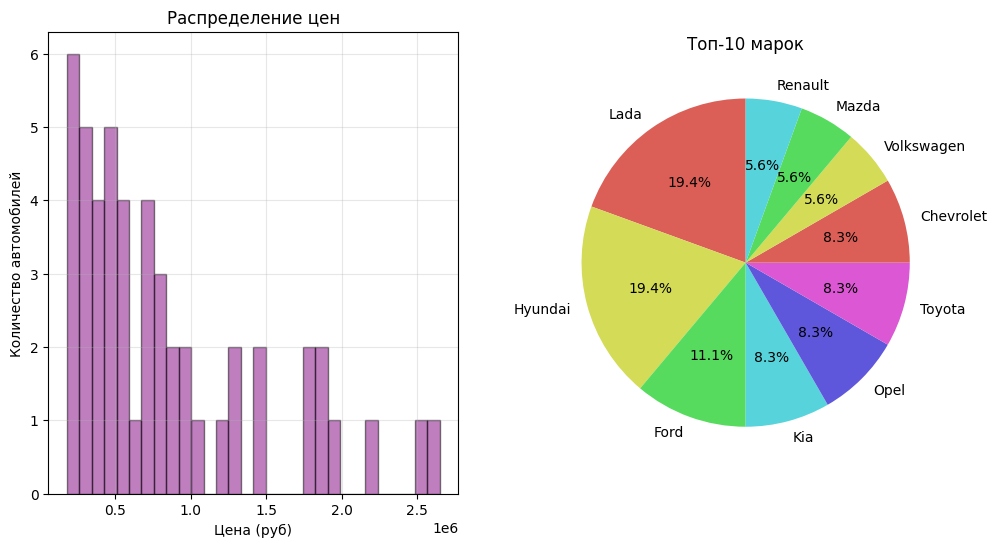

In [4]:
plt.figure(figsize=(18, 6))

# Первый график: Гистограмма цен
plt.subplot(1, 3, 1)
plt.hist(df['price'], bins=30, alpha=0.5, color='purple', edgecolor='black')
plt.title('Распределение цен')
plt.xlabel('Цена (руб)')
plt.ylabel('Количество автомобилей')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
top_10_brands = df['brand'].value_counts().head(10)
plt.pie(top_10_brands.values, labels=top_10_brands.index, autopct='%1.1f%%', startangle=90)
plt.title('Топ-10 марок')

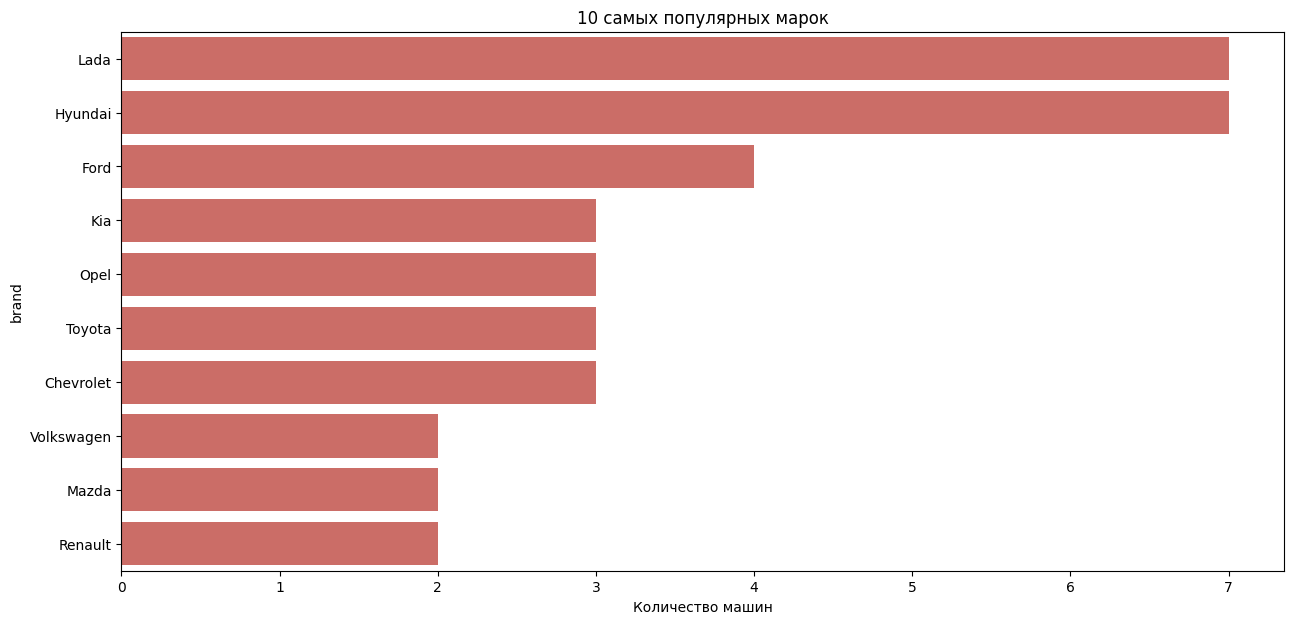

In [13]:
top_brands = df['brand'].value_counts().head(10)

plt.figure(figsize=(15, 7))
sns.barplot(x=top_brands.values, y=top_brands.index)
plt.title('10 самых популярных марок')
plt.xlabel('Количество машин')
plt.show()

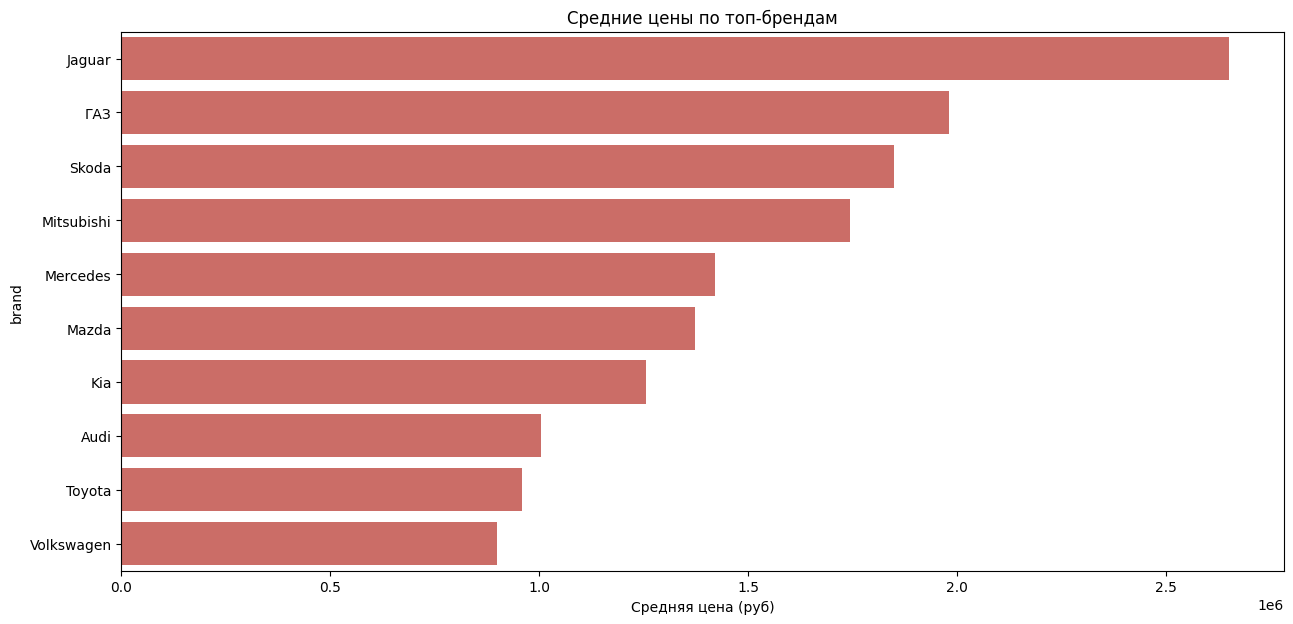

In [5]:
brand_prices = df.groupby('brand')['price'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(15, 7))
sns.barplot(x=brand_prices.values, y=brand_prices.index)
plt.title('Средние цены по топ-брендам')
plt.xlabel('Средняя цена (руб)')
plt.show()


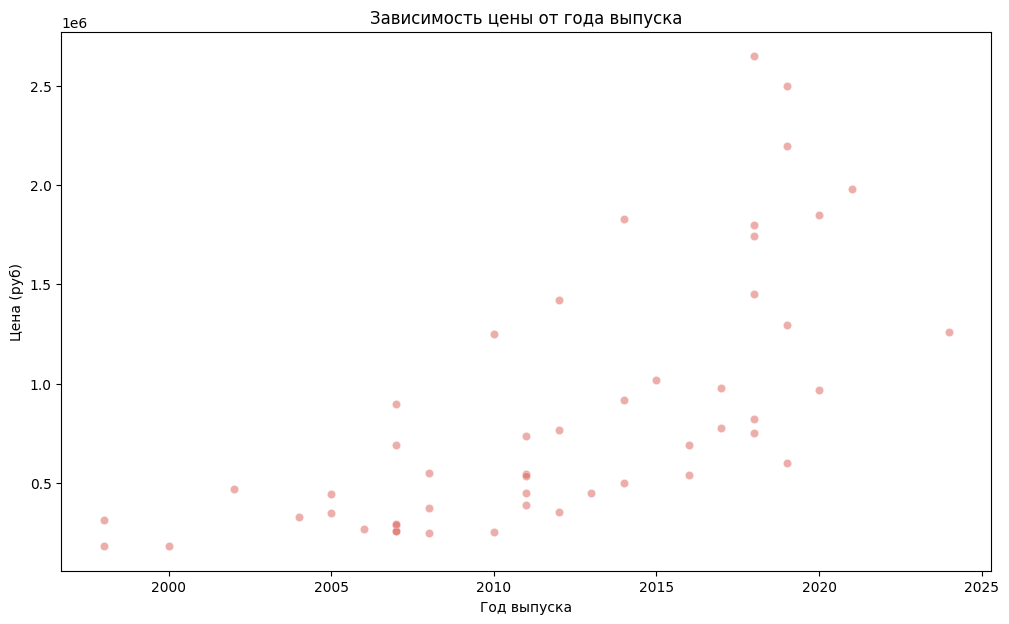

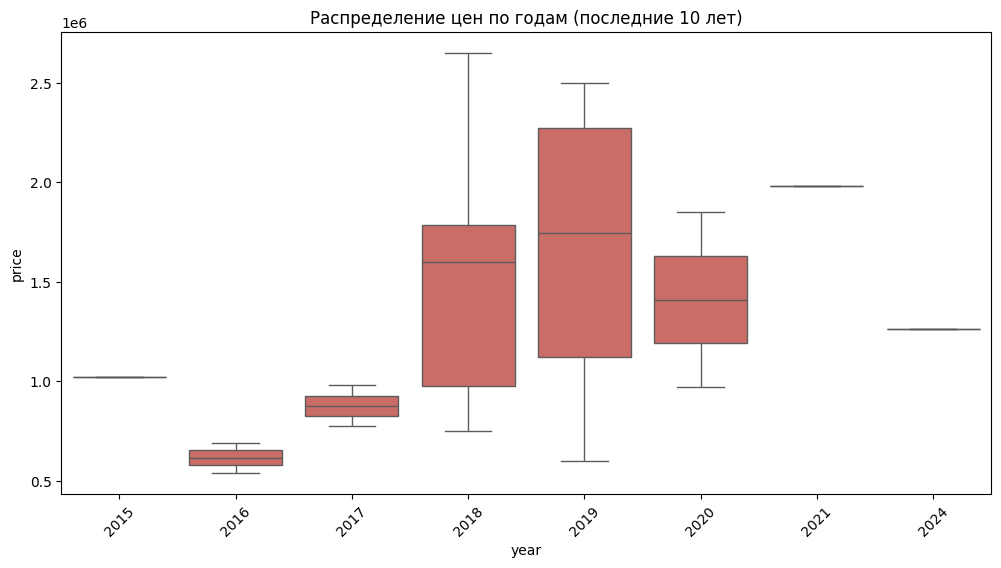

In [6]:
from datetime import datetime  # Добавьте эту строку
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='year', y='price', alpha=0.5)
plt.title('Зависимость цены от года выпуска')
plt.xlabel('Год выпуска')
plt.ylabel('Цена (руб)')
plt.show()

recent_years = df[df['year'] >= (datetime.now().year - 10)]
plt.figure(figsize=(12, 6))
sns.boxplot(data=recent_years, x='year', y='price')
plt.title('Распределение цен по годам (последние 10 лет)')
plt.xticks(rotation=45)
plt.show()